# Customer Churn Prediction

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import numpy as np

In [49]:
df = pd.read_csv("data/cleaned_data.csv")

In [50]:
df.head()

,customer_id,signup_date,last_active_date,age,region,city_raw,customer_segment,acquisition_channel,product_plan,device_type,monthly_sessions,avg_monthly_spend,discount_pct,support_tickets_90d,satisfaction_score,estimated_income_czk,payment_method,churned,satisfaction_missing,city_clean
0,100001,2025-01-31,2026-04-23,39,prague,praha,family,organic search,basic,desktop,9,633.59,13.9,3,7.8,99500,card,0,0,prague
1,100002,2025-12-30,2026-04-27,53,brno,brno,family,email campaign,business,desktop,22,15337.56,4.2,2,5.9,68800,unknown,0,0,brno
2,100003,2024-05-10,2026-04-20,27,olomouc,olomouc,family,organic search,premium,tablet,9,3772.14,19.9,2,4.7,62600,card,0,0,olomouc
3,100004,2025-07-18,2026-04-05,28,brno,brno,small business,email campaign,plus,mobile,15,3633.56,4.8,0,8.6,54200,paypal,0,0,brno
4,100005,2025-03-22,2026-04-09,54,ostrava,ostrava,family,social media,business,mobile,13,4665.13,12.8,2,10.0,38800,card,0,0,ostrava


# Prepare data

In [51]:
df = df.drop( ['customer_id', 'signup_date', 'last_active_date', 'city_raw'], axis=1)

In [52]:
X = df.drop('churned', axis=1)
y = df['churned']

In [53]:
ct = ColumnTransformer(
    transformers=[
        (
            'encoder',
            OneHotEncoder(),
            [
                'region',
                'customer_segment',
                'acquisition_channel',
                'product_plan',
                'device_type',
                'payment_method',
                'city_clean'
            ]
        )
    ],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)

In [54]:
ohe_feature_names = ct.named_transformers_['encoder'].get_feature_names_out([
    'region', 'customer_segment', 'acquisition_channel',
    'product_plan', 'device_type', 'payment_method', 'city_clean'
])
numeric_cols = ['age', 'monthly_sessions', 'avg_monthly_spend', 'discount_pct',
                'support_tickets_90d', 'satisfaction_score', 
                'estimated_income_czk', 'satisfaction_missing']
all_feature_names = list(ohe_feature_names) + numeric_cols

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 1, stratify=y)

In [56]:
# feature scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Train data

## Logistic regression

In [57]:
lr = LogisticRegression(random_state = 0, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [58]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1505  541]
 [  23   47]]
              precision    recall  f1-score   support

           0       0.98      0.74      0.84      2046
           1       0.08      0.67      0.14        70

    accuracy                           0.73      2116
   macro avg       0.53      0.70      0.49      2116
weighted avg       0.96      0.73      0.82      2116



In [59]:
y_proba = lr.predict_proba(X_test_scaled)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.7794651584974165


## Random forest 

In [60]:
rf = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 0, max_depth=10, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [61]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1922  124]
 [  49   21]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2046
           1       0.14      0.30      0.20        70

    accuracy                           0.92      2116
   macro avg       0.56      0.62      0.58      2116
weighted avg       0.95      0.92      0.93      2116



In [62]:
y_proba = rf.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.7828236279849183


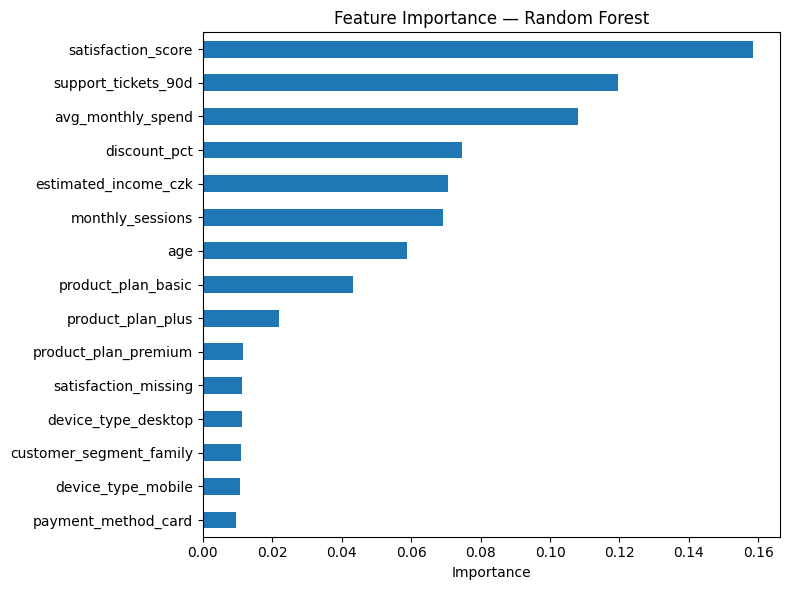

In [63]:
# from model evaluation, the biggest impact has satisfaction_score, support_tickets last 90 days and avg_monthly_spend
feat_imp = pd.Series(rf.feature_importances_, index=all_feature_names)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)  # top 15

feat_imp.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Gradient Boosting 

In [64]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

weights = compute_sample_weight('balanced', y_train)
gb.fit(X_train, y_train, sample_weight=weights)
y_pred = gb.predict(X_test)

In [65]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1647  399]
 [  29   41]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.89      2046
           1       0.09      0.59      0.16        70

    accuracy                           0.80      2116
   macro avg       0.54      0.70      0.52      2116
weighted avg       0.95      0.80      0.86      2116



In [66]:
y_proba = gb.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.7842061164641809


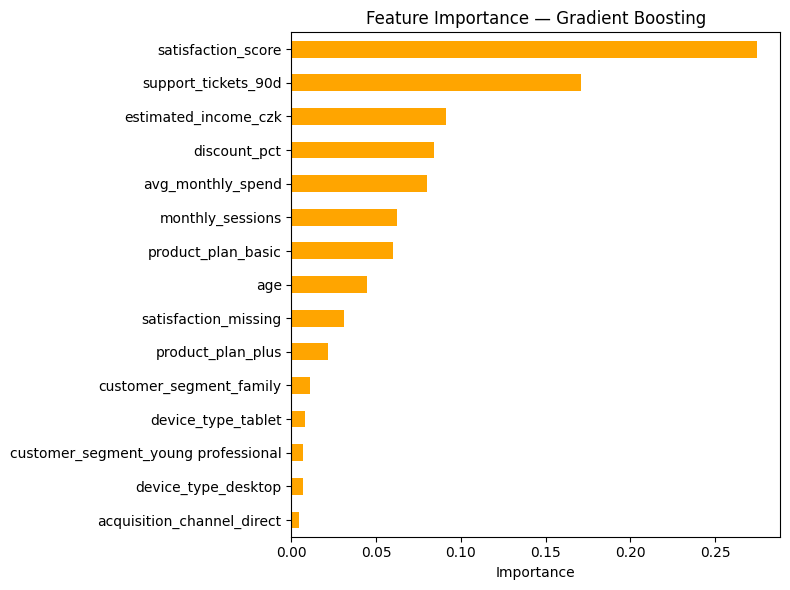

In [ ]:
# gb evaluated satisfaction_score ae most important, then support_tickets
feat_imp_gb = pd.Series(gb.feature_importances_, index=all_feature_names)
feat_imp_gb = feat_imp_gb.sort_values(ascending=True).tail(15)

feat_imp_gb.plot(kind='barh', figsize=(8, 6), color='orange')
plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

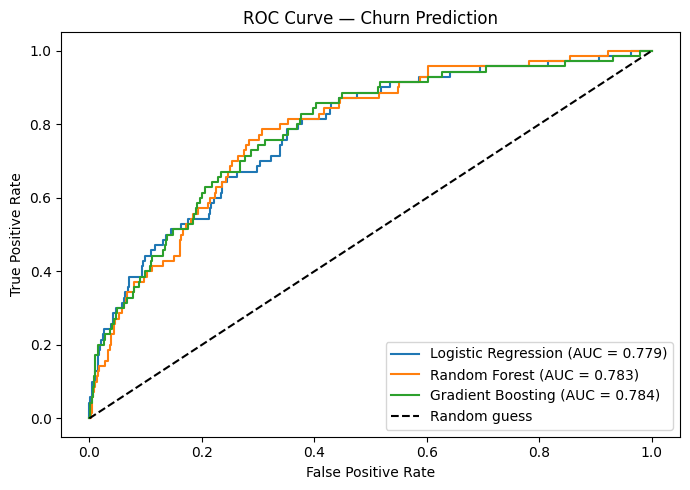

In [ ]:
# Get probabilities for each model
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]
gb_proba = gb.predict_proba(X_test)[:, 1]

# Plot
plt.figure(figsize=(7, 5))

for name, proba in [('Logistic Regression', lr_proba), 
                     ('Random Forest', rf_proba), 
                     ('Gradient Boosting', gb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.show()

All three are extremely close on ROC-AUC — GB wins by a hair. LR has the best recall. 
Satisfaction score and count of support tickets last 90 days are main factors to predict churn clients.